## Chapter 2

In [2]:
import numpy as np

In [3]:
import torch
from torch.distributions import Binomial

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns
import pyro
import pyro.distributions as dist

from rethinking import MAP, precis

### 2.1

In [6]:
p = np.array([0,.25,.5,.75,1])
c = np.array([0,3,8,9,0])

In [7]:
c/np.sum(c)

array([0.  , 0.15, 0.4 , 0.45, 0.  ])

### 2.3 Building a model

In [8]:
binom = Binomial(9,0.5)
binom.log_prob(torch.tensor(6)).exp()

tensor(0.1641)

### 2.4 Making the Model Go

#### Grid Approximation

In [9]:
n = 20
p_grid = torch.linspace(0,1,n)
prior = torch.ones_like(p_grid)
likelihood = Binomial(9,p_grid).log_prob(torch.tensor(6)).exp()
unstd_posterior = likelihood * prior
posterior = unstd_posterior/torch.sum(unstd_posterior)

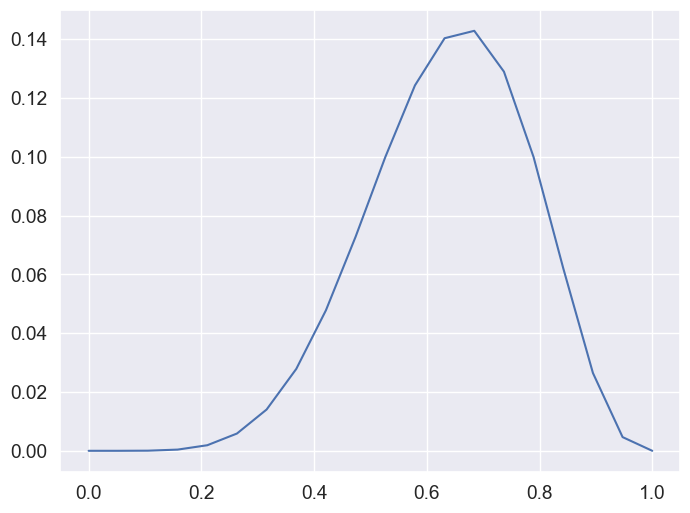

In [10]:
plt.plot(p_grid,posterior)

#### Quad Apprx

I think we're still running into the problem where windows doesn't let jupyter notebook parallelize things.

In [24]:
def model(w):
    p = pyro.sample('p',dist.Uniform(0,1))
    pyro.sample("w",dist.Binomial(9,p),obs=w)

globe_qa = MAP(model).run(torch.tensor(6))

precis(globe_qa)

,Mean,StdDev,|0.89,0.89|
p,0.53,0.14,0.31,0.75


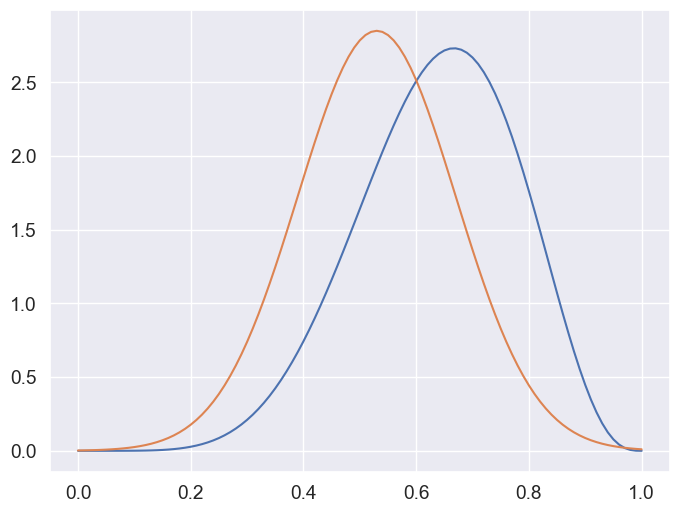

In [25]:
w = 6
n = 9
x = torch.linspace(0, 1, 101)
plt.figure()
ax = plt.plot(x, dist.Beta(w + 1, n - w + 1).log_prob(x).exp())
#ax.set(xlabel="proportion water", ylabel="Density", title="n = 9")
# quadratic approximation
precis_df = precis(globe_qa)
plt.plot(x, dist.Normal(precis_df["Mean"][0],
                            precis_df["StdDev"][0]).log_prob(x).exp())
#ax.lines[1].set_linestyle("--")

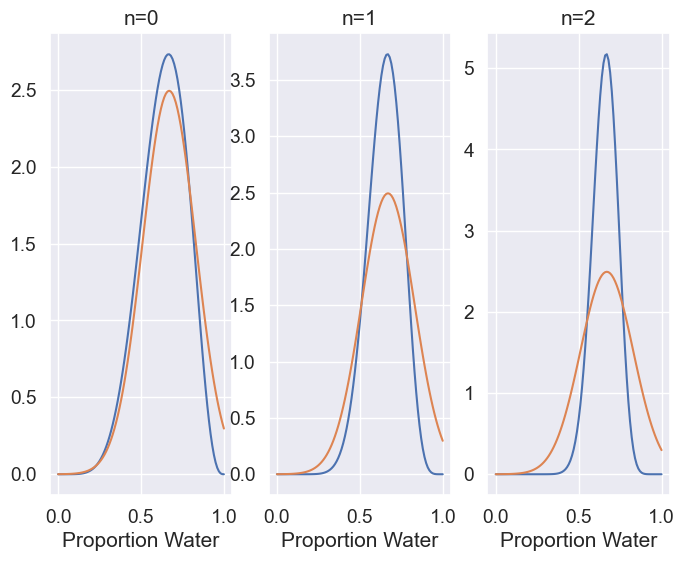

In [27]:
fig, axs = plt.subplots(1,3)
for i, ax in enumerate(axs):
    n, w = 9, 6
    if i == 1:
        n, w = 18, 12
    elif i == 2:
        n, w = 36, 24

    ax.plot(x,dist.Beta(w+1,n-w+1).log_prob(x).exp())
    ax.plot(x,dist.Normal(0.67,0.16).log_prob(x).exp())

    ax.set_title(f'n={i}')
    ax.set_xlabel('Proportion Water')
